# SAC baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms import FourRoomsGridWorld, FourRoomsGoalWrapper
from networks import SAC_Critic
from agents import SAC_Actor
from utils import TrajectoryReplayBuffer, collect_episode, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics 

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9,9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env

In [ ]:
def sac_train(
    total_steps=300000,
    warmup_steps=10000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    lr=3e-4,
    alpha_lr=3e-4,
    train_freq=1,
):
    env = make_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    print(f"Observation dim: {obs_dim}, Action dim: {act_dim}")

    actor = SAC_Actor(obs_dim, act_dim).to(DEVICE)
    q1 = SAC_Critic(obs_dim, act_dim).to(DEVICE)
    q2 = SAC_Critic(obs_dim, act_dim).to(DEVICE)
    q1_target = SAC_Critic(obs_dim, act_dim).to(DEVICE)
    q2_target = SAC_Critic(obs_dim, act_dim).to(DEVICE)

    q1_target.load_state_dict(q1.state_dict())
    q2_target.load_state_dict(q2.state_dict())

    for p in list(q1_target.parameters()) + list(q2_target.parameters()):
        p.requires_grad_(False)

    actor_opt = optim.Adam(actor.parameters(), lr=lr)
    q_opt = optim.Adam(list(q1.parameters()) + list(q2.parameters()), lr=lr)

    log_alpha = torch.tensor(
        np.log(0.8), dtype=torch.float32, device=DEVICE, requires_grad=True
    )
    alpha_opt = optim.Adam([log_alpha], lr=alpha_lr)
    target_entropy = -float(act_dim)

    replay = TrajectoryReplayBuffer(
        capacity=100000,
        obs_dim=obs_dim,
        action_dim=act_dim,
        device=DEVICE,
    )

    total_env_steps = 0
    grad_steps = 0
    eval_returns = []

    obs, _ = env.reset()

    while total_env_steps < warmup_steps:
        action = env.action_space.sample().astype(np.float32)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay.add_transition(obs, action, reward, next_obs, done)

        obs = next_obs
        total_env_steps += 1
        if done:
            obs, _ = env.reset()

    while total_env_steps < total_steps:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            action_t, _ = actor.sample(obs_t)

        action = action_t[0].detach().cpu().numpy().astype(np.float32)

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay.add_transition(obs, action, reward, next_obs, done)

        obs = next_obs
        total_env_steps += 1
        if done:
            obs, _ = env.reset()

        if total_env_steps % train_freq == 0:
            batch = replay.sample(batch_size)

            obs_b = batch.obs.float()
            act_b = batch.actions.float()
            rew_b = batch.rewards.float()
            next_obs_b = batch.next_obs.float()
            done_b = torch.clamp(batch.terminated + batch.truncated, 0, 1).float()

            with torch.no_grad():
                next_a_b, next_logp_b = actor.sample(next_obs_b)
                target_q1 = q1_target(next_obs_b, next_a_b)
                target_q2 = q2_target(next_obs_b, next_a_b)
                target_q = torch.min(target_q1, target_q2) - log_alpha.exp() * next_logp_b
                y = rew_b + gamma * (1.0 - done_b) * target_q

            q1_pred = q1(obs_b, act_b)
            q2_pred = q2(obs_b, act_b)
            q_loss = F.mse_loss(q1_pred, y) + F.mse_loss(q2_pred, y)

            q_opt.zero_grad()
            q_loss.backward()
            q_opt.step()

            new_a_b, logp_b = actor.sample(obs_b)
            q_pi = torch.min(q1(obs_b, new_a_b), q2(obs_b, new_a_b))
            actor_loss = (log_alpha.exp().detach() * logp_b - q_pi).mean()

            actor_opt.zero_grad()
            actor_loss.backward()
            actor_opt.step()

            alpha_loss = -(log_alpha * (-logp_b.detach() - target_entropy)).mean()

            alpha_opt.zero_grad()
            alpha_loss.backward()
            alpha_opt.step()

            with torch.no_grad():
                for p, pt in zip(q1.parameters(), q1_target.parameters()):
                    pt.data.mul_(1 - tau).add_(tau * p.data)
                for p, pt in zip(q2.parameters(), q2_target.parameters()):
                    pt.data.mul_(1 - tau).add_(tau * p.data)

            grad_steps += 1

        if grad_steps > 0 and grad_steps % 200 == 0:
            eval_env = make_env()

            def eval_actor(o):
                o_t = torch.as_tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                with torch.no_grad():
                    mu, _ = actor(o_t)
                    a = torch.tanh(mu)
                return a[0].cpu().numpy().astype(np.float32)

            mean_ret, mean_len = evaluate_policy(
                eval_env,
                eval_actor,
                episodes=8,
            )
            eval_returns.append((total_env_steps, mean_ret))
            print(
                f"[SAC] step={total_env_steps:7d} | "
                f"eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}"
            )
            eval_env.close()

    env.close()
    return actor, q1, eval_returns

sac_actor, sac_q1, sac_eval = sac_train()

if sac_eval:
    xs, ys = zip(*sac_eval)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("SAC baseline on FourRooms")
    plt.grid(alpha=0.25)
    plt.show()

Observation dim: 2, Action dim: 2
Step 10000: obs_t shape: torch.Size([1, 2]), obs_t: tensor([[5.4888, 8.4741]], device='mps:0')


/var/folders/2g/2k53tjhj7sz_z3c4ws9dvcsr0000gn/T/ipykernel_82572/385612895.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)


Step 10001: obs_t shape: torch.Size([1, 256, 2]), obs_t: tensor([[[9.0174e+00, 4.1799e+00],
         [5.7492e-01, 1.0783e+01],
         [1.0995e+01, 2.6229e+00],
         [1.4636e+00, 4.5295e+00],
         [1.5127e+00, 8.2376e-01],
         [3.5062e+00, 2.6073e+00],
         [2.8246e-01, 9.3352e+00],
         [3.3815e-01, 8.7029e+00],
         [4.6263e+00, 1.0352e+01],
         [1.0286e+01, 6.7469e+00],
         [1.9472e+00, 7.4349e-01],
         [2.6268e+00, 8.6527e+00],
         [3.1504e-01, 9.4619e+00],
         [4.5612e+00, 3.3699e+00],
         [3.2262e+00, 1.0284e+00],
         [4.5137e+00, 1.3787e+00],
         [5.0917e-01, 8.0508e+00],
         [2.9883e+00, 3.9671e-01],
         [6.0133e-01, 3.5123e-03],
         [2.7750e+00, 9.1927e+00],
         [6.7328e+00, 6.9417e+00],
         [7.9321e-01, 2.1986e+00],
         [8.8005e+00, 4.9466e+00],
         [8.7893e+00, 1.3845e+00],
         [1.0069e+01, 8.8073e+00],
         [9.9978e+00, 7.8693e+00],
         [8.3205e+00, 2.7931e+00]

ValueError: Expected action shape (2,), got (512,)

## Visualisations

Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 500 steps | return: 0.00 | reached goal: False
Episode 4: 500 steps | return: 0.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


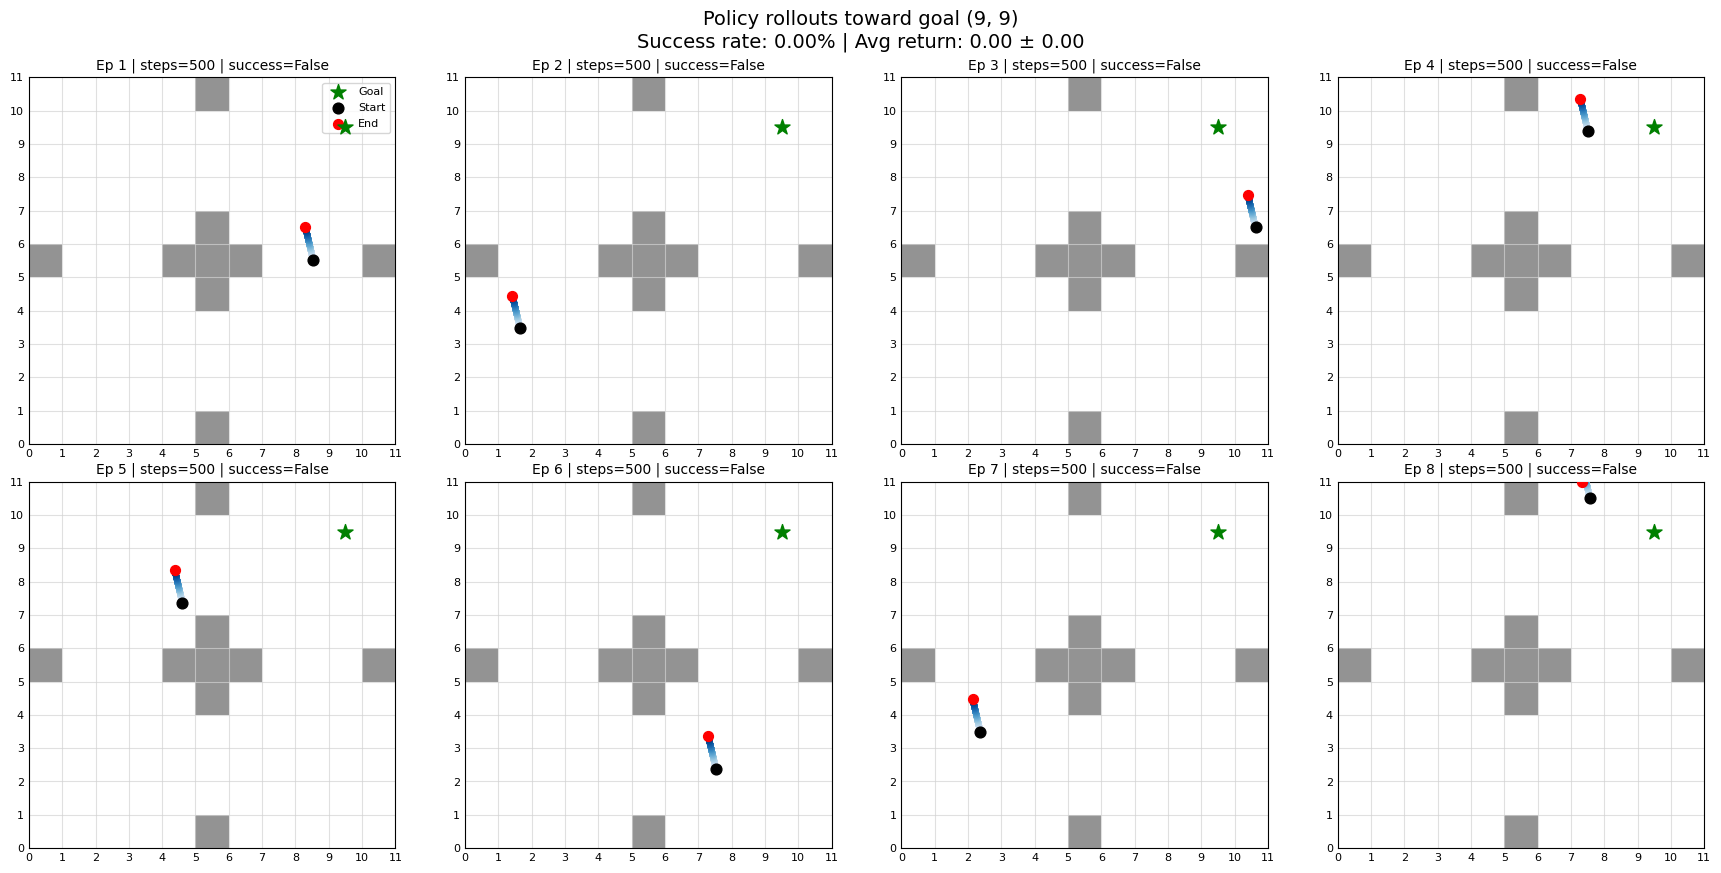

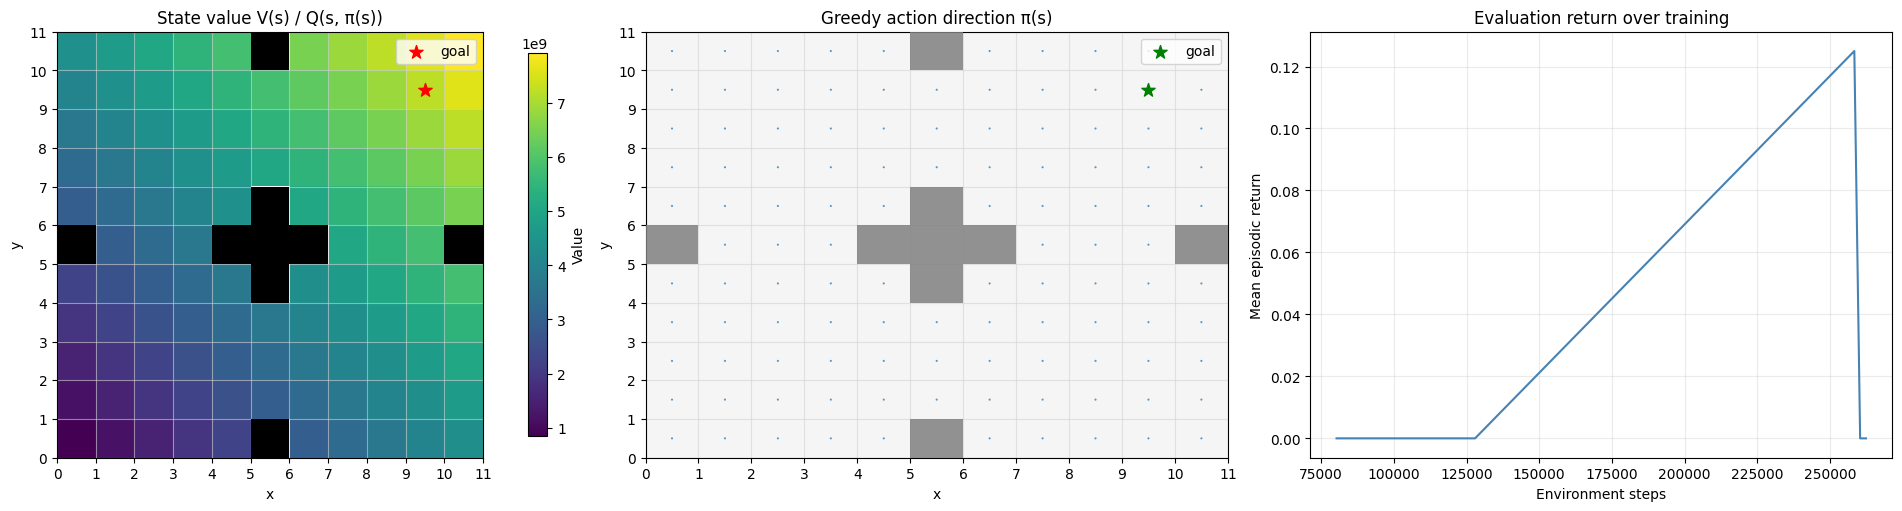

In [ ]:

sac_actor.eval()
sac_q1.eval()

eval_env = make_env(goal=(9, 9))


def sac_policy_fn(obs):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        mu, _ = sac_actor(obs_t)
        action = torch.tanh(mu).squeeze(0).cpu().numpy().astype(np.float32)
    return action


def sac_value_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        mu, _ = sac_actor(obs_t)
        a = torch.tanh(mu)
        q = sac_q1(obs_t, a).squeeze(-1).cpu().numpy()
    return q


def sac_actor_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        mu, _ = sac_actor(obs_t)
        actions = torch.tanh(mu).cpu().numpy()
    return actions


plot_policy_rollouts(
    env=eval_env,
    policy_fn=sac_policy_fn,
    goal_pos=(9, 9),
    eval_episodes=8,
    n_cols=4,
    is_discrete=False,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

eval_env.close()

eval_env = make_env(goal=(9, 9))

plot_q_diagnostics(
    env=eval_env,
    value_fn=sac_value_fn,
    actor_fn=sac_actor_fn,
    is_discrete=False,
    goal_pos=(9, 9),
    eval_returns=sac_eval,
)

eval_env.close()